Setup

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 44.7 MB/s eta 0:00:00


Kernel restart

In [2]:
from IPython import get_ipython
if get_ipython():
    get_ipython().kernel.do_shutdown(restart=True)


Loading data

In [2]:
import pandas as pd
df=pd.read_csv('/content/Baza customer Telecom v2.csv')


Understanding data

In [3]:
print("Shape",df.shape)
print("\nColumns:\n",df.columns)
print("\ninfo:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Shape (8453, 14)

Columns:
 Index(['PID', 'CRM_PID_Value_Segment', 'EffectiveSegment', 'Billing_ZIP',
       'KA_name', 'Active_subscribers', 'Not_Active_subscribers',
       'Suspended_subscribers', 'Total_SUBs', 'AvgMobileRevenue ',
       'AvgFIXRevenue', 'TotalRevenue', 'ARPU', 'CHURN'],
      dtype='object')

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-nul

4.Data Cleaning

In [4]:
df.drop(['PID'],axis=1,inplace=True)
df.drop('Suspended_subscribers', axis=1, inplace=True)
df['Not_Active_subscribers']=df['Not_Active_subscribers'].fillna(0)
df['ARPU']=df['ARPU'].fillna(df['ARPU'].median())
df['Billing_ZIP']=df['Billing_ZIP'].fillna(df['Billing_ZIP'].mode()[0])
df['CRM_PID_Value_Segment']=df['CRM_PID_Value_Segment'].fillna("Unknown")

In [5]:
df['CHURN']=df['CHURN'].map({'Yes':1,'No':0})


In [6]:
print(df.isnull().sum())
print("\n",df.duplicated().sum())
df['CHURN'].value_counts()

CRM_PID_Value_Segment     0
EffectiveSegment          0
Billing_ZIP               0
KA_name                   0
Active_subscribers        0
Not_Active_subscribers    0
Total_SUBs                0
AvgMobileRevenue          0
AvgFIXRevenue             0
TotalRevenue              0
ARPU                      0
CHURN                     0
dtype: int64

 20


,count
CHURN,
0,7904
1,549


In [7]:
duplicates = df[df.duplicated()]
duplicates.head()

,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
587,Bronze,SOHO,6000.0,DI,5,1.0,6,61.00,0.0,61.00,12.20,0
925,Bronze,SOHO,6600.0,RJ,4,1.0,5,72.00,0.0,72.00,18.00,0
959,Bronze,SOHO,6100.0,AD?,4,0.0,4,72.83,0.0,72.83,18.21,0
1209,Bronze,SOHO,6000.0,VM,5,0.0,5,80.83,0.0,80.83,16.17,0
1675,Bronze,SOHO,6300.0,RJ,4,0.0,4,96.17,0.0,96.17,24.04,0


In [8]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
545,Bronze,SOHO,4000.0,AD,3,3.0,6,59.83,0.0,59.83,19.94,0
7085,Bronze,SOHO,4000.0,AD,3,3.0,6,59.83,0.0,59.83,19.94,0
308,Bronze,SOHO,4000.0,AD,5,0.0,5,51.33,0.0,51.33,10.27,0
8247,Bronze,SOHO,4000.0,AD,5,0.0,5,51.33,0.0,51.33,10.27,0
8422,Bronze,SOHO,4000.0,Daniela Stefanova,2,0.0,2,55.83,0.0,55.83,27.92,0
8425,Bronze,SOHO,4000.0,Daniela Stefanova,2,0.0,2,55.83,0.0,55.83,27.92,0
5502,Bronze,SOHO,4000.0,Ginka Vachkova,3,0.0,3,69.00,0.0,69.00,23.00,0
5508,Bronze,SOHO,4000.0,Ginka Vachkova,3,0.0,3,69.00,0.0,69.00,23.00,0
8171,Bronze,SOHO,4000.0,VT,1,0.0,1,49.33,0.0,49.33,49.33,0
8174,Bronze,SOHO,4000.0,VT,1,0.0,1,49.33,0.0,49.33,49.33,0


In [9]:
df = df.drop_duplicates()

In [10]:
df['CRM_PID_Value_Segment'] = df['CRM_PID_Value_Segment'].replace('Sliver', 'Silver')

In [11]:
df.shape

(8433, 12)

EDA

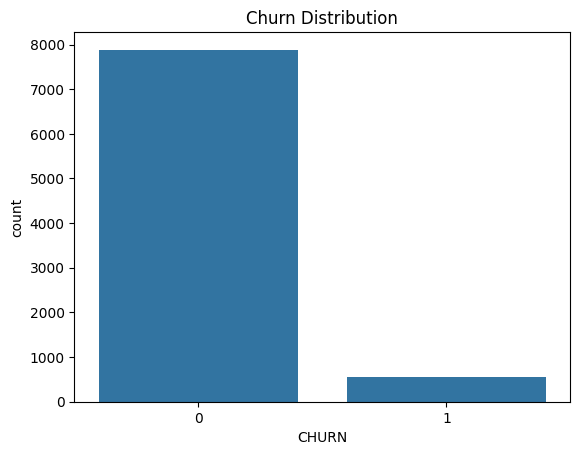

CHURN
0    0.934899
1    0.065101
Name: proportion, dtype: float64


In [12]:

import seaborn as sns
import matplotlib.pyplot as plt
#Churn Distribution
sns.countplot(x='CHURN', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['CHURN'].value_counts(normalize=True))

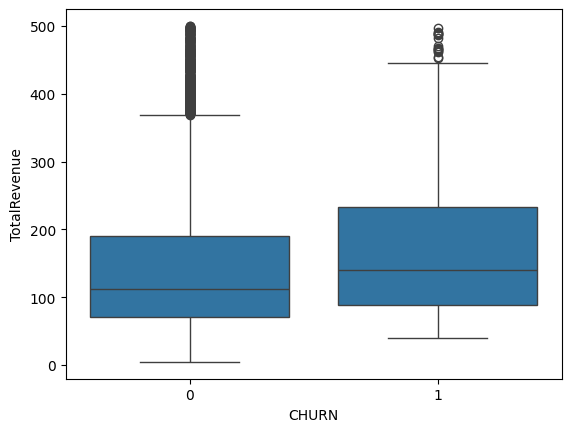

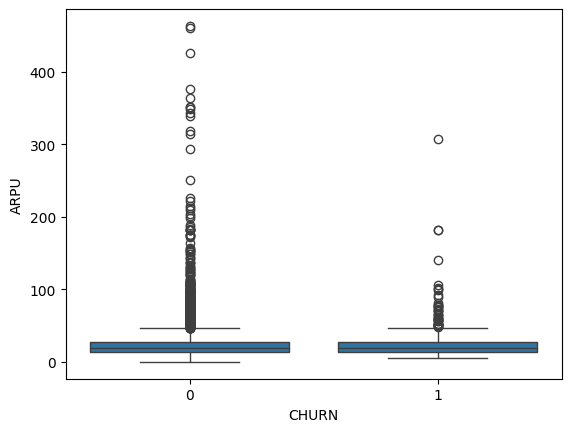

In [13]:
#Revenue vs Churn
sns.boxplot(x='CHURN', y='TotalRevenue', data=df)
plt.show()

sns.boxplot(x='CHURN', y='ARPU', data=df)
plt.show()

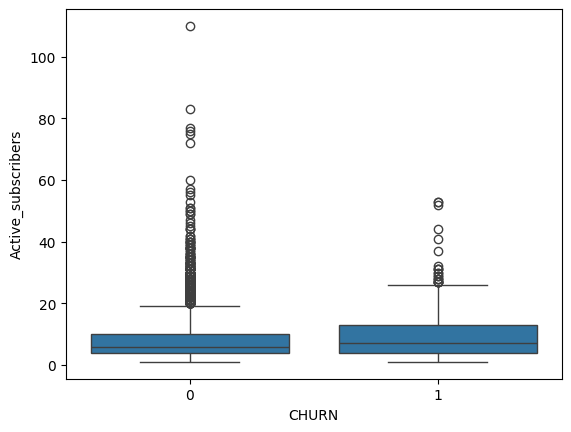

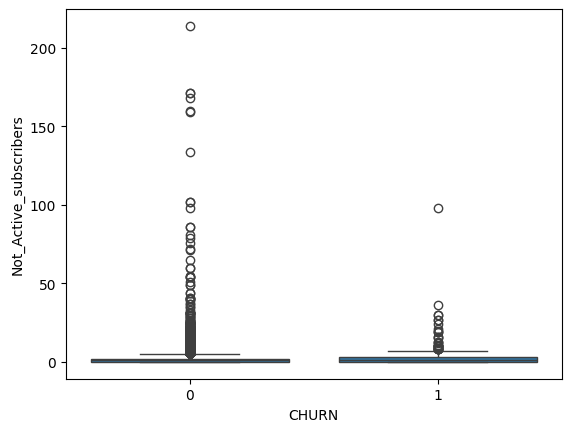

In [14]:
#Subscriber Behavior
sns.boxplot(x='CHURN', y='Active_subscribers', data=df)
plt.show()

sns.boxplot(x='CHURN', y='Not_Active_subscribers', data=df)
plt.show()

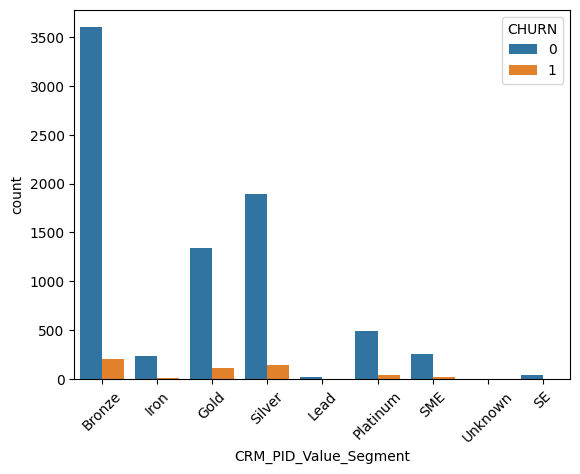

In [15]:
#Segment Analysis
sns.countplot(x='CRM_PID_Value_Segment', hue='CHURN', data=df)
plt.xticks(rotation=45)
plt.show()

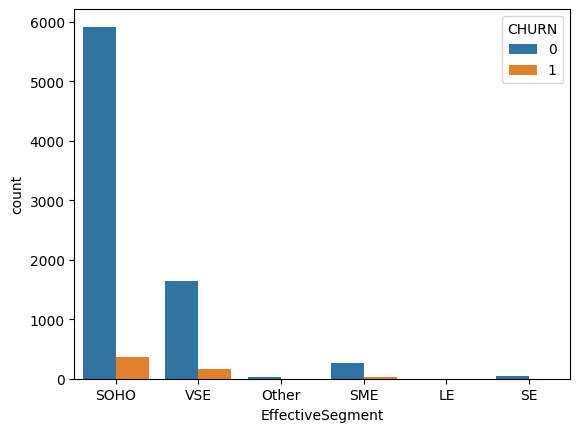

In [16]:
#Customer Type
sns.countplot(x='EffectiveSegment', hue='CHURN', data=df)
plt.show()

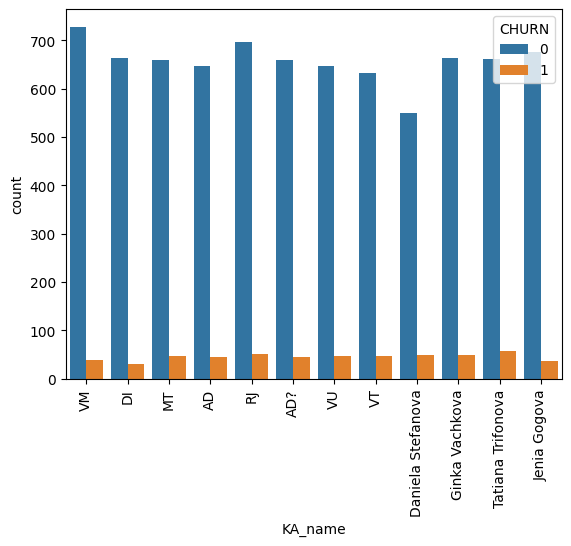

In [17]:
#Account Manager Impact
sns.countplot(x='KA_name', hue='CHURN', data=df)
plt.xticks(rotation=90)
plt.show()

Feature Engineering

In [18]:
freq = df['KA_name'].value_counts()
df['KA_name_encoded'] = df['KA_name'].map(freq)
df.drop('KA_name', axis=1, inplace=True)

In [19]:
segment_mapping = {
    'Iron': 0,
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3,
    'Platinum': 4,
    'Lead': 5,
    'SME': 6,
    'SE': 7,
    'Unknown': -1
}

df['CRM_PID_Value_Segment'] = df['CRM_PID_Value_Segment'].map(segment_mapping)

In [20]:
df = pd.get_dummies(df, columns=['EffectiveSegment'], drop_first=True)

In [21]:
df.head()
df.shape

(8433, 16)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8433 entries, 0 to 8452
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CRM_PID_Value_Segment   8433 non-null   int64  
 1   Billing_ZIP             8433 non-null   float64
 2   Active_subscribers      8433 non-null   int64  
 3   Not_Active_subscribers  8433 non-null   float64
 4   Total_SUBs              8433 non-null   int64  
 5   AvgMobileRevenue        8433 non-null   float64
 6   AvgFIXRevenue           8433 non-null   float64
 7   TotalRevenue            8433 non-null   float64
 8   ARPU                    8433 non-null   float64
 9   CHURN                   8433 non-null   int64  
 10  KA_name_encoded         8433 non-null   int64  
 11  EffectiveSegment_Other  8433 non-null   bool   
 12  EffectiveSegment_SE     8433 non-null   bool   
 13  EffectiveSegment_SME    8433 non-null   bool   
 14  EffectiveSegment_SOHO   8433 non-null   bool 

Model Building

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x=df.drop('CHURN',axis=1)
y=df['CHURN']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [24]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x_train_scaled, y_train)

In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(x_res,y_res)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [26]:
# from sklearn.ensemble import RandomForestClassifier
# rf=RandomForestClassifier(class_weight='balanced',random_state=42)
# rf.fit(x_train_scaled,y_train)

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_res, y_res)

GradientBoostingClassifier(random_state=42)

Evaluation

In [34]:
#prediction
y_prob = lr.predict_proba(x_test_scaled)[:,1]
#y_pred_lr=lr.predict(x_test)
y_pred_lr_new = (y_prob > 0.52).astype(int)
#y_pred_rf=rf.predict(x_test_scaled)
y_prob_gb = gb.predict_proba(x_test_scaled)[:, 1]
#y_pred_gb=gb.predict(x_test_scaled)
y_pred_gb_new = (y_prob_gb > 0.33).astype(int)

In [35]:
#metrics
from sklearn.metrics import classification_report,confusion_matrix
print("Logistic Regression:\n")
print(classification_report(y_test,y_pred_lr_new))
print(confusion_matrix(y_test,y_pred_lr_new))

# print("\nRandom Forest:\n")
# print(confusion_matrix(y_test,y_pred_rf))
# print(classification_report(y_test,y_pred_rf))
print("Gradient Boosting:\n")
print(classification_report(y_test,y_pred_gb_new))
print(confusion_matrix(y_test,y_pred_gb_new))



Logistic Regression:

              precision    recall  f1-score   support

           0       0.94      0.75      0.84      1578
           1       0.09      0.34      0.14       109

    accuracy                           0.73      1687
   macro avg       0.51      0.55      0.49      1687
weighted avg       0.89      0.73      0.79      1687

[[1187  391]
 [  72   37]]
Gradient Boosting:

              precision    recall  f1-score   support

           0       0.94      0.82      0.88      1578
           1       0.09      0.25      0.13       109

    accuracy                           0.78      1687
   macro avg       0.51      0.53      0.50      1687
weighted avg       0.89      0.78      0.83      1687

[[1296  282]
 [  82   27]]
